In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

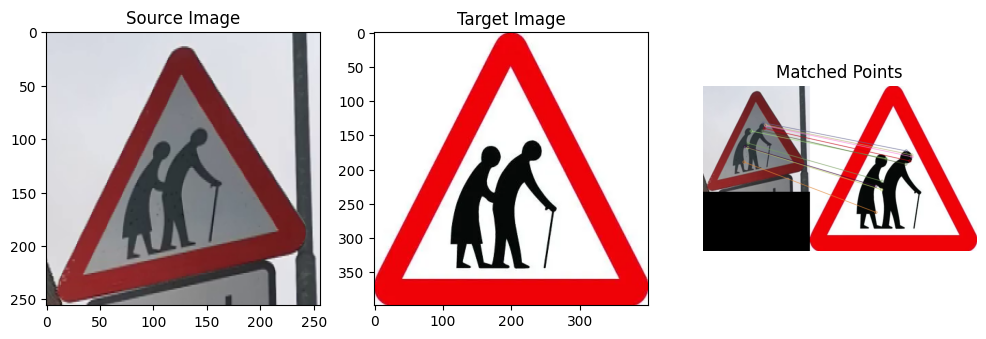

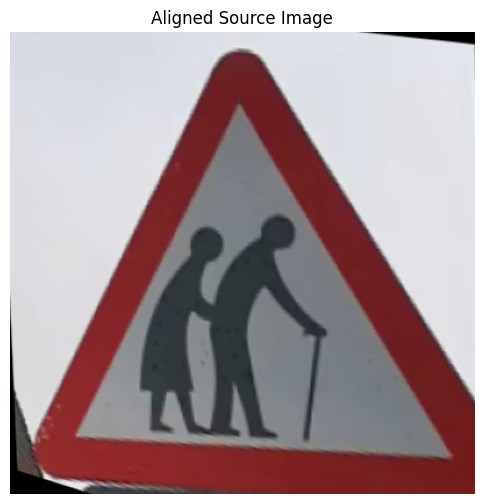

In [10]:
def manually_align_images(source, target):
    # Load images in grayscale
    source_img = cv2.imread(source, cv2.IMREAD_GRAYSCALE)
    target_img = cv2.imread(target, cv2.IMREAD_GRAYSCALE)

    # Initialize the output images for visualization
    source_color = cv2.imread(source)
    target_color = cv2.imread(target)

    # Manually select points in the source and target images
    def select_points(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))

    points = []

    # Display the target and source images to select points manually
    cv2.imshow("Select Points - Source Image", source_color)
    cv2.setMouseCallback("Select Points - Source Image", select_points)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    print(f"Selected points from source: {points}")
    
    # Repeat for target image
    points_target = []
    cv2.imshow("Select Points - Target Image", target_color)
    cv2.setMouseCallback("Select Points - Target Image", select_points)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    print(f"Selected points from target: {points_target}")
    
    # Calculate homography from manually selected points
    src_pts = np.float32(points).reshape(-1, 1, 2)
    tgt_pts = np.float32(points_target).reshape(-1, 1, 2)

    # Compute the homography matrix
    H, mask = cv2.findHomography(src_pts, tgt_pts, cv2.RANSAC, 5.0)
    
    # Warp the source image
    height, width = target_img.shape
    aligned_source = cv2.warpPerspective(source_color, H, (width, height))

    # Draw the correspondence points
    matched_img = cv2.drawMatches(source_color, points, target_color, points_target, [], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    return aligned_source, matched_img

def automatically_align_images(source, target):
    # Load images in grayscale
    source_img = cv2.imread(source, cv2.IMREAD_GRAYSCALE)
    target_img = cv2.imread(target, cv2.IMREAD_GRAYSCALE)

    # Initialize the output images for visualization
    source_color = cv2.imread(source)
    target_color = cv2.imread(target)

    # Use ORB (can be replaced with SIFT/SURF if available)
    orb = cv2.ORB_create()

    # Detect keypoints and descriptors
    kp1, des1 = orb.detectAndCompute(source_img, None)
    kp2, des2 = orb.detectAndCompute(target_img, None)

    # Match descriptors using BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    
    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)

    # Extract the corresponding points
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    tgt_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Compute the homography
    H, mask = cv2.findHomography(src_pts, tgt_pts, cv2.RANSAC, 5.0)

    # Warp the source image to align with the target
    height, width = target_img.shape
    aligned_source = cv2.warpPerspective(source_color, H, (width, height))

    # Draw the matches
    matched_img = cv2.drawMatches(source_color, kp1, target_color, kp2, matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    return aligned_source, matched_img


def align_images(source, target, selection='automatic'):
    # Initialize the output images for visualization
    source_color = cv2.imread(source)
    target_color = cv2.imread(target)

    # Feature detection and matching
    if selection == 'automatic':
        aligned_source, matched_img = automatically_align_images(source, target)
    elif selection == 'manual':
        aligned_source, matched_img = manually_align_images(source, target)

    # Display the results
    plt.figure(figsize=(12, 6))

    # Display source and target images with points
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(source_color, cv2.COLOR_BGR2RGB))
    plt.title('Source Image')
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(target_color, cv2.COLOR_BGR2RGB))
    plt.title('Target Image')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.title('Matched Points')
    plt.axis("off")
    plt.show()

    # Display the aligned source image
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(aligned_source, cv2.COLOR_BGR2RGB))
    plt.title('Aligned Source Image')
    plt.axis("off")
    plt.show()

# Example usage
align_images('Task-3/frail.png', 'Task-3/frail_reference.webp', 'automatic')
# align_images('Task-3/zebra_crossing1.png', 'Task-3/zebra_crossing_reference.jpg', 'automatic')
# align_images('Task-3/zebra_crossing2.png', 'Task-3/zebra_crossing_reference.jpg', 'manual')
